# Building a linear-Gaussian state-space model


<div class="note"><span class="note-t">TL;DR</span>
<p>We unroll a <a href="#ref-kalman-1960">linear-Gaussian state-space model</a> into affine gates with time-homogeneous parameters, condition on all observations, and inspect an offline event score from the exact <a href="#ref-rts-1965">smoothed posterior</a>. A dense NumPy recursion plus a Schur complement independently verify the prior propagation and conditioning algebra.</p>
</div>


In this tutorial, we build a [linear-Gaussian state-space model](#ref-kalman-1960) in Torx and read an offline event score from its exact smoothed posterior.

Six synthetic Gaussian observation channels are generated directly from a 3-dimensional latent state. Each latent state and observation is a **pmode**, a continuous Torx site valued in $\mathbb{R}^N$ and tracked by its mean and covariance.

This example is time-homogeneous: the same dynamics and emission parameters apply at every time step. Torx represents that assumption by explicitly unrolling the sequence into per-step gates while reusing the same transition and emission `theta` values.

The full program has an initial gate, shared-parameter transition gates, and per-step emission gates. All are `AffineGaussianGate` instances.

<details class="tx-disclosure"><summary>Term: smoothing</summary><p>Smoothing estimates latent states using the full observation sequence, including observations from later time steps. It is an offline, acausal calculation.</p></details>

By the end, you'll be able to:

- build one initial gate, one gate per transition, and one per emission,
- condition on all observations to get the exact smoothed posterior, equivalent to [Kalman filtering (1960)](#ref-kalman-1960) followed by [Rauch-Tung-Striebel smoothing (1965)](#ref-rts-1965), and
- run a one-seed oracle-axis sanity check against a dense NumPy prior recursion and conditioning formula.



## Setup

The setup cells import dependencies and define `_det_log_var`, a material helper that assigns exact zero variance to deterministic passthrough coordinates.

<details class="tx-disclosure"><summary>What runs where?</summary><ul>
<li>Torx gates build the joint Gaussian and compute the exact smoothed posterior.</li>
<li>Notebook code generates the Gaussian observations, implements the dense reference, and computes the uncalibrated score.</li>
<li><code>examples/helpers/_plots_fields.py</code> and <code>examples/helpers/_plots_schematics.py</code> render the supplied arrays and circuit semantics.</li>
<li><code>examples/helpers/_notebook_paths.py</code> and <code>examples/helpers/_notebook_style.py</code> manage offline figure paths and style.</li>
</ul></details>

In [1]:
from pathlib import Path
import sys

import jax.numpy as jnp
import numpy as np



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_fields as P_fld
import _plots_schematics as P_sch
from torx.psc import AffineGaussianGate, HybridPCircuit



In [4]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 23
rng = np.random.default_rng(SEED)


savefig = make_savefig(FIGURE_DIR)




In [5]:
def _det_log_var(dim):
    """Log-variance of a noise-free (deterministic) affine channel."""
    return jnp.full((dim,), -jnp.inf)


## The model

A 3-dimensional latent state (`latent_dim = 3`) carries the hidden drive.

Six synthetic Gaussian observation channels (`num_channels = 6`) are generated directly by the observation equation below.

The model is linear-Gaussian:

$$
z_0 \sim \mathcal{N}(m_0,\,P_0),\qquad
z_t = \underbrace{A\,z_{t-1}}_{\vphantom{\big|}\text{drift}} + \underbrace{\varepsilon_t}_{\vphantom{\big|}\text{process noise}},
$$
$$
x_t = C\,z_t + \eta_t.
$$

The initial state draws from the prior $\mathcal{N}(m_0,P_0)$. The process noise is $\varepsilon_t \sim \mathcal{N}(0,Q)$, the measurement noise is $\eta_t \sim \mathcal{N}(0,R)$, and $C$ is the observation map.

The transition sub-product uses the same transition parameters at every adjacent pair:

$$
G_{\mathrm{trans}}(\theta)=\underbrace{\prod_{t=1}^{T-1}}_{\vphantom{\big|}\text{$T-1$ transitions}} \underbrace{K_\theta^{(t-1,\,t)}}_{\vphantom{\big|}\text{same theta reused}} .
$$

Each factor $K_\theta^{(t-1,\,t)}$ is the transition kernel from latent site $t-1$ to latent site $t$, and every factor reuses the same `theta`.

This sharing is inference-time reuse of the same fixed `theta` values: the built circuit is explicitly unrolled into one gate per transition and one gate per emission, and each gate aliases the same `theta` dictionary. There is no compact scan primitive and no trainable parameter tying involved. Under a normal JAX optimizer the repeated gates would receive separate gradients, so training would require an explicit gate-to-theta reduction. The initial gate carries the prior $\mathcal{N}(m_0,P_0)$, and the emission gates carry the observation map $C$ and measurement noise $R$.

One length-$T$ sequence is therefore one initial gate, $T-1$ transition gates that reuse the same transition `theta`, and $T$ emission gates that reuse the same emission `theta`.

The exact-inference construction below uses `log_var = -inf` on deterministic passthrough coordinates. That is exact for conditioning, but not differentiable through those coordinates. Clamp to a large finite-negative value before training with gradients.


The next cell sets the dimensions that define the latent and observation sites, plus the fixed `intent_axis` used later to score the drive.

In [6]:
T = 32
latent_dim = 3
num_channels = 6

latent_sites = list(range(T))
obs_sites = list(range(T, 2 * T))
intent_axis = np.array([1.0, 0.35, -0.25])

The transition matrix `A` specifies the latent dynamics from one time step to the next.

In [7]:
A = np.array(
    [
        [0.92, 0.08, 0.00],
        [-0.04, 0.88, 0.06],
        [0.02, -0.08, 0.90],
    ]
)

The observation matrix `C` maps the latent state into six continuous channels.

In [8]:
C = np.array(
    [
        [1.15, 0.10, -0.15],
        [0.85, -0.25, 0.05],
        [-0.35, 0.95, 0.20],
        [0.20, 0.45, 0.85],
        [-0.10, -0.55, 1.05],
        [0.55, 0.15, -0.65],
    ]
)

The prior mean `m0` and the diagonal covariance parameters set the initial uncertainty (`P0_diag`), process noise (`Q_diag`), and measurement noise (`R_diag`).

In [9]:
m0 = np.array([-0.45, 0.15, 0.10])
P0_diag = np.array([0.35, 0.25, 0.20])
Q_diag = np.array([0.055, 0.045, 0.040])
R_diag = np.array([0.16, 0.18, 0.20, 0.17, 0.19, 0.16])

`simulate_lgssm` draws one latent trajectory and six Gaussian observation channels with plain NumPy.

In [10]:
def simulate_lgssm():
    z = np.zeros((T, latent_dim))
    x = np.zeros((T, num_channels))
    # Draw the prior state and its first noisy observation.
    z[0] = rng.multivariate_normal(m0, np.diag(P0_diag))
    x[0] = C @ z[0] + rng.normal(scale=np.sqrt(R_diag))
    for t in range(1, T):
        # Reuse the same dynamics and noise scale at each later step.
        z[t] = A @ z[t - 1] + rng.normal(scale=np.sqrt(Q_diag))
        x[t] = C @ z[t] + rng.normal(scale=np.sqrt(R_diag))
    return z, x

A synthetic Gaussian trial supplies `observations` for conditioning and hidden `true_event` labels for the one-seed sanity check.

In [11]:
true_latent, observations = simulate_lgssm()
true_drive = true_latent @ intent_axis

true_event_threshold = 0.0
true_event = true_drive > true_event_threshold
true_event_rate = float(true_event.mean())
majority_baseline_acc = max(true_event_rate, 1.0 - true_event_rate)

print(f"T={T}, latent_dim={latent_dim}, num_channels={num_channels}")
print(f"true events active: {true_event.sum()} / {T}  (rate = {true_event_rate:.1%})")
print(f"majority-class baseline accuracy: {majority_baseline_acc:.1%}")

T=32, latent_dim=3, num_channels=6
true events active: 12 / 32  (rate = 37.5%)
majority-class baseline accuracy: 62.5%


A shape check catches simulation mistakes before the circuit uses the data.

In [12]:
np.testing.assert_equal(true_latent.shape, (T, latent_dim))
np.testing.assert_equal(observations.shape, (T, num_channels))


The printed `true_event_rate` gives the `majority_baseline_acc` used later for the detector comparison.

## Building the circuit

Each time index has one latent pmode and one observation pmode.

The transition gates implement the kernel $K_\theta^{(t-1,\,t)}$ above; the initial and emission gates carry the prior and the observation model:

- Initial gate ($t=0$): encodes the prior $z_0 \sim \mathcal{N}(m_0, P_0)$ as a single-site `AffineGaussianGate`.
- Transition gate ($t=1\ldots T-1$): uses a block matrix that copies $z_{t-1}$ and writes $z_t = A z_{t-1}$, with process noise $Q$ on the new site.
- Emission gate ($t=0\ldots T-1$): uses a block matrix that copies $z_t$ and writes $x_t = C z_t$, with measurement noise $R$ on the observation site.

Passthrough coordinates use `log_var = -inf` via the visible `_det_log_var` helper above, so they are deterministic copies. The block structure carries the model, and the gate list repeats it across time by aliasing the same fixed `theta`.

The matrices `transition_matrix` and `emission_matrix` make the deterministic passthrough coordinates explicit.

In [13]:
# First block copies z_{t-1}; second block writes the next latent state.
transition_matrix = np.block(
    [
        [np.eye(latent_dim), np.zeros((latent_dim, latent_dim))],
        [A, np.zeros((latent_dim, latent_dim))],
    ]
)

# First block keeps z_t; second block writes the predicted observation.
emission_matrix = np.block(
    [
        [np.eye(latent_dim), np.zeros((latent_dim, num_channels))],
        [C, np.zeros((num_channels, num_channels))],
    ]
)

The initial gate `initial_gate` writes the Gaussian prior onto the first latent site.

In [14]:
initial_gate = AffineGaussianGate(
    sites=[latent_sites[0]],
    dims=(latent_dim,),
)
initial_theta = {
    "A": jnp.zeros((latent_dim, latent_dim)),
    "b": jnp.asarray(m0),
    "log_var": jnp.log(jnp.asarray(P0_diag)),
}

The transition gates in `transition_gates` unroll adjacent time steps while reusing the same transition parameter dictionary.


In [15]:
transition_gates = [
    AffineGaussianGate(
        sites=[latent_sites[t - 1], latent_sites[t]],
        dims=(latent_dim, latent_dim),
    )
    for t in range(1, T)
]
transition_theta = {
    "A": jnp.asarray(transition_matrix),
    "b": jnp.zeros(2 * latent_dim),
    "log_var": jnp.concatenate(
        [
            _det_log_var(latent_dim),
            jnp.log(jnp.asarray(Q_diag)),
        ]
    ),
}
transition_thetas = [transition_theta for _ in range(1, T)]

The emission gates in `emission_gates` attach one observed pmode to each latent time step.

In [16]:
emission_gates = [
    AffineGaussianGate(
        sites=[latent_sites[t], obs_sites[t]],
        dims=(latent_dim, num_channels),
    )
    for t in range(T)
]
emission_theta = {
    "A": jnp.asarray(emission_matrix),
    "b": jnp.zeros(latent_dim + num_channels),
    "log_var": jnp.concatenate(
        [
            _det_log_var(latent_dim),
            jnp.log(jnp.asarray(R_diag)),
        ]
    ),
}
emission_thetas = [emission_theta for _ in range(T)]

`HybridPCircuit` combines the gate groups into the full unrolled circuit, with one `theta` per gate collected in a matching list.

In [17]:
circuit = HybridPCircuit([initial_gate, *transition_gates, *emission_gates])
# Parameters live outside the circuit, one theta per gate in gate order.
thetas = [initial_theta, *transition_thetas, *emission_thetas]
np.testing.assert_equal(len(thetas), len(circuit.gates))

print(f"{len(circuit.gates)} AffineGaussianGate instances")
print(f"  1 initial + {T - 1} transition + {T} emission = {1 + (T - 1) + T}")


64 AffineGaussianGate instances
  1 initial + 31 transition + 32 emission = 64


A dimension check confirms the latent and observed site layout in `circuit`.

In [18]:
np.testing.assert_equal(circuit.continuous_dims, (latent_dim,) * T + (num_channels,) * T)


The printed count confirms that one initial gate, 31 transition gates, and 32 emission gates represent the model.

One time slice contains a transition followed by an emission. The directed schematic labels the parameters, written coordinates, and passthrough wires.

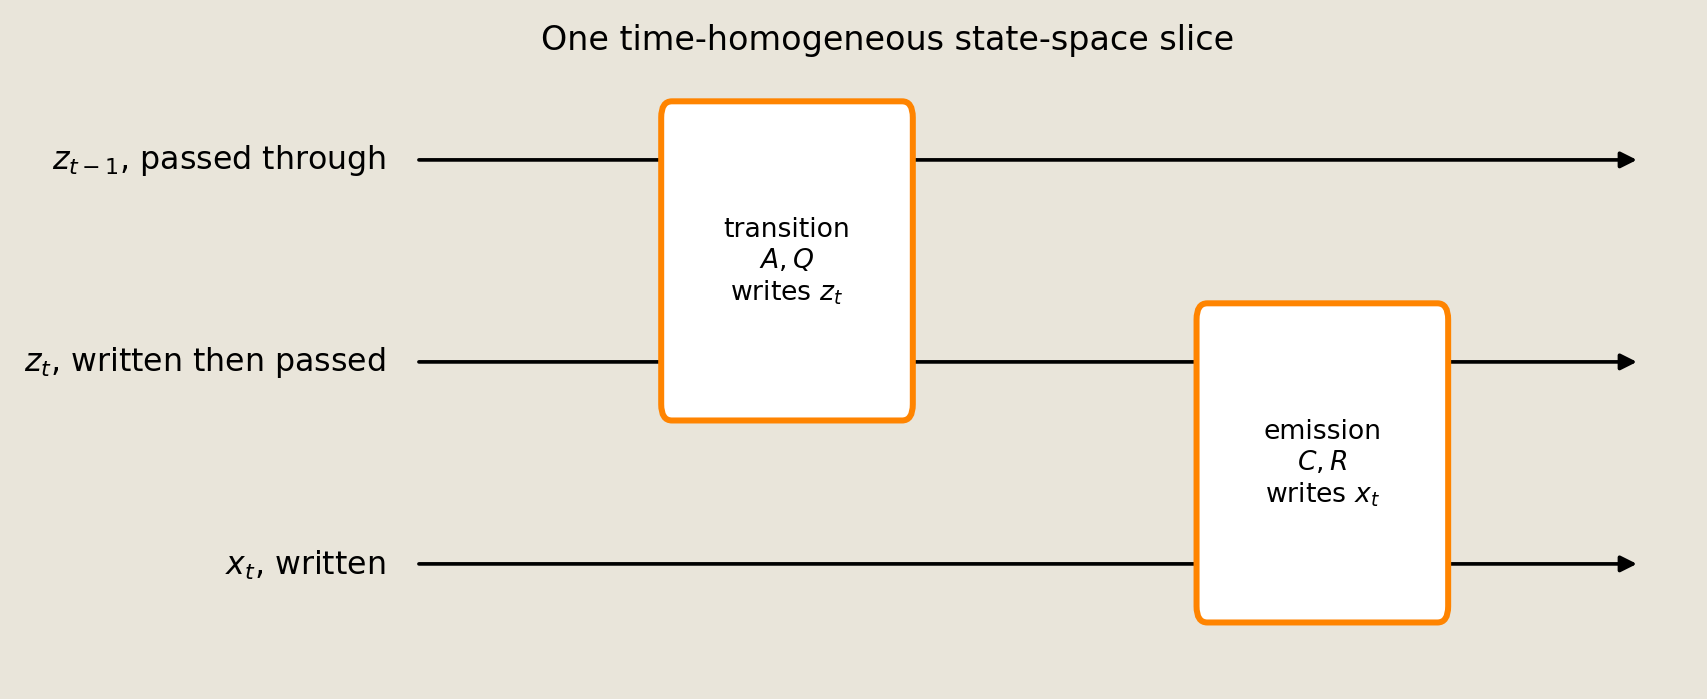

In [19]:
fig_c = P_sch.plot_ssm_slice_circuit()
savefig(fig_c, "11_ssm_slice_circuit")

The slice writes $z_t$ with transition parameters $A,Q$, then writes $x_t$ with emission parameters $C,R$ while passing the source coordinates through.

## Exact posterior

For a linear-Gaussian model, conditioning the joint Gaussian on the full observation sequence gives the same smoothed posterior as [Kalman filtering (1960)](#ref-kalman-1960) followed by the backward pass of [Rauch, Tung, and Striebel (1965)](#ref-rts-1965).

`AffineGaussianSimulator.condition` conditions on all 32 observations at once. The result is exact for this model, offline, and acausal because each latent estimate can use later observations.

We compile the circuit for `AffineGaussianSimulator`, then condition on the observed pmodes in `observed` and query the latent pmodes in `latent_sites`.

In [20]:
observed = {site: jnp.asarray(observations[t]) for t, site in enumerate(obs_sites)}
from torx.psc import AffineGaussianSimulator
affine_sim = AffineGaussianSimulator()
compiled = affine_sim.build_circuit(circuit, thetas)

# flat initial continuous state over all latent + observed sites
initial_continuous = jnp.zeros(T * latent_dim + T * num_channels)



In [21]:
# Condition on observed sites, then return moments only for the latent sites.
posterior = affine_sim.condition(
    compiled,
    observations=observed,
    initial_continuous=initial_continuous,
    query_sites=latent_sites,
)
posterior_mean = np.asarray(posterior.mean).reshape(T, latent_dim)
posterior_cov = np.asarray(posterior.covariance)

A dense NumPy baseline independently propagates the LGSSM moments from `(A, C, Q, R, m0, P0)` and then applies the Schur-complement conditioning formula. Torx must match both the dense prior and dense posterior to within the relative and absolute tolerances asserted below.


In [22]:
def dense_lgssm_joint_moments(A, C, m0, P0_diag, Q_diag, R_diag, T):
    A = np.asarray(A, dtype=float)
    C = np.asarray(C, dtype=float)
    m0 = np.asarray(m0, dtype=float)
    Q = np.diag(np.asarray(Q_diag, dtype=float))
    R = np.diag(np.asarray(R_diag, dtype=float))
    latent_dim = A.shape[0]
    num_channels = C.shape[0]

    z_mean = np.zeros((T, latent_dim))
    z_cov = np.zeros((T, T, latent_dim, latent_dim))
    z_mean[0] = m0
    z_cov[0, 0] = np.diag(np.asarray(P0_diag, dtype=float))
    for t in range(1, T):
        z_mean[t] = A @ z_mean[t - 1]
        for s in range(t):
            cov_ts = A @ z_cov[t - 1, s]
            z_cov[t, s] = cov_ts
            z_cov[s, t] = cov_ts.T
        z_cov[t, t] = A @ z_cov[t - 1, t - 1] @ A.T + Q

    total_dim = T * latent_dim + T * num_channels
    mean = np.zeros(total_dim)
    cov = np.zeros((total_dim, total_dim))
    obs_mean = z_mean @ C.T
    mean[: T * latent_dim] = z_mean.reshape(-1)
    mean[T * latent_dim :] = obs_mean.reshape(-1)

    def z_slice(t):
        return slice(t * latent_dim, (t + 1) * latent_dim)

    def x_slice(t):
        start = T * latent_dim + t * num_channels
        return slice(start, start + num_channels)

    for t in range(T):
        for s in range(T):
            cov_zz = z_cov[t, s]
            cov[z_slice(t), z_slice(s)] = cov_zz
            cov[z_slice(t), x_slice(s)] = cov_zz @ C.T
            cov[x_slice(t), z_slice(s)] = C @ cov_zz
            cov_xx = C @ cov_zz @ C.T
            if t == s:
                cov_xx = cov_xx + R
            cov[x_slice(t), x_slice(s)] = cov_xx
    return mean, cov




First, propagate the Torx prior through every site and check it against the dense joint moments.

In [23]:
prior = affine_sim.propagate(compiled, initial_continuous)
dense_prior_mean, dense_prior_cov = dense_lgssm_joint_moments(
    A, C, m0, P0_diag, Q_diag, R_diag, T
)
np.testing.assert_equal(prior.sites, tuple(latent_sites + obs_sites))
np.testing.assert_allclose(prior.mean, dense_prior_mean, rtol=1e-5, atol=3e-5)
np.testing.assert_allclose(prior.covariance, dense_prior_cov, rtol=1e-5, atol=3e-5)



Then condition the dense joint on the observations. The Schur complement gives the reference posterior mean and covariance for the Torx result to match.

In [24]:
latent_total = T * latent_dim
query_idx = np.arange(latent_total)
obs_idx = np.arange(latent_total, latent_total + T * num_channels)
y = observations.reshape(-1)



In [25]:
# condition returns query_sites in latent_sites order, matching query_idx.
Soo = dense_prior_cov[np.ix_(obs_idx, obs_idx)]
Sqo = dense_prior_cov[np.ix_(query_idx, obs_idx)]
Sqq = dense_prior_cov[np.ix_(query_idx, query_idx)]
dense_mean = dense_prior_mean[query_idx] + Sqo @ np.linalg.solve(
    Soo, y - dense_prior_mean[obs_idx]
)
dense_cov = Sqq - Sqo @ np.linalg.solve(Soo, Sqo.T)



In [26]:
np.testing.assert_allclose(posterior.mean, dense_mean, rtol=1e-5, atol=3e-5)
np.testing.assert_allclose(posterior.covariance, dense_cov, rtol=1e-5, atol=3e-5)
np.testing.assert_equal(posterior_mean.shape, (T, latent_dim))
np.testing.assert_array_less(-1e-6, np.linalg.eigvalsh(posterior_cov))


A structural check bins the smoothed covariance into per-timestep blocks. Most of the mass should sit on the diagonal, with the nearest-neighbor lag dominating the off-diagonal terms.

In [27]:
block_norms = np.array(
    [
        [
            np.linalg.norm(
                posterior_cov[
                    t * latent_dim : (t + 1) * latent_dim,
                    s * latent_dim : (s + 1) * latent_dim,
                ]
            )
            for s in range(T)
        ]
        for t in range(T)
    ]
)
lag_mean_norms = np.array(
    [np.mean([block_norms[t, t + lag] for t in range(T - lag)]) for lag in range(T)]
)
offdiag_lag_means = lag_mean_norms[1:]
np.testing.assert_equal(int(np.argmax(offdiag_lag_means)), 0)
np.testing.assert_array_less(np.mean(lag_mean_norms[4:]), lag_mean_norms[1])
print(f"mean block norms by lag 0..4: {lag_mean_norms[:5].round(4).tolist()}")


mean block norms by lag 0..4: [0.056699998676776886, 0.027799999341368675, 0.014000000432133675, 0.0071000000461936, 0.003700000001117587]


The next cell computes the model log-evidence from the dense reference: the log-probability of the observed data under the model.

In [28]:
# Soo is an SPD observation covariance, so take its log-det from the Cholesky
# factor: the stable SPD path, and it raises LinAlgError if Soo is ever not
# positive definite instead of returning a quietly wrong number.
chol_Soo = np.linalg.cholesky(Soo)
logdet = float(2.0 * np.sum(np.log(np.diag(chol_Soo))))
y_centered = y - dense_prior_mean[obs_idx]
log_evidence = float(
    -0.5
    * (
        len(y) * np.log(2 * np.pi)
        + logdet
        + y_centered @ np.linalg.solve(Soo, y_centered)
    )
)
print("Torx matches the independent dense LGSSM baseline")
print(f"log-evidence: {log_evidence:.3f}")


Torx matches the independent dense LGSSM baseline
log-evidence: -152.580


The printed `log_evidence` scores this observed trial under the dense reference model. Compare candidate models only on the same observations and with the same likelihood conventions.

## Offline event-score sanity check

Projecting `posterior_mean` onto `intent_axis` gives a scalar latent drive. Each step's per-site covariance marginal gives the variance of that projection.

`intent_axis` is fixed in advance and also defines the hidden labels. The result is therefore a one-seed oracle-axis latent-recovery sanity check, not a decoder benchmark.

The binary prediction uses the median of the complete smoothed trajectory. Both the threshold and smoothed posterior use future time bins, making this a retrospective full-trial analysis.

The posterior drive `posterior_drive` and its standard deviation `posterior_drive_std` come from the smoothed latent moments.

In [29]:
posterior_drive = posterior_mean @ intent_axis
posterior_drive_var = np.array(
    [
        # Project each smoothed covariance onto the same one-dimensional intent axis.
        intent_axis @ np.asarray(posterior.site_moments(s)[1]) @ intent_axis
        for s in latent_sites
    ]
)
posterior_drive_std = np.sqrt(np.maximum(posterior_drive_var, 0.0))

The logistic transform is an uncalibrated display score centered on the full-trial median. Its 0.5 decision is identical to `posterior_drive > detection_threshold`.

In [30]:
detection_threshold = float(np.median(posterior_drive))
# Center the uncalibrated score at the full-trial median.
uncalibrated_score = 1.0 / (1.0 + np.exp(-3.0 * (posterior_drive - detection_threshold)))
predicted_event = posterior_drive > detection_threshold

For this one seeded oracle-axis check, accuracy, [AUC](https://doi.org/10.1016/j.patrec.2005.10.010), precision, recall, and confusion counts summarize latent-drive recovery. Their scope is this synthetic trial only.

In [31]:
accuracy = float(np.mean(predicted_event == true_event))

pos = posterior_drive[true_event]
neg = posterior_drive[~true_event]
# AUC and precision/recall are undefined without both classes present.
assert pos.size and neg.size, "metrics require both event and non-event steps"
# tie-aware AUC (Mann-Whitney): ties between a positive and negative get half credit
gt = float((pos[:, None] > neg[None, :]).mean())
eq = float((pos[:, None] == neg[None, :]).mean())
auc = gt + 0.5 * eq



In [32]:
tp = int(np.sum(predicted_event & true_event))
fp = int(np.sum(predicted_event & ~true_event))
fn = int(np.sum(~predicted_event & true_event))
tn = int(np.sum(~predicted_event & ~true_event))
# report undefined metrics as nan rather than masking an empty denominator
precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall = tp / (tp + fn) if (tp + fn) else float("nan")



In [33]:
if accuracy < majority_baseline_acc + 0.05:
    raise AssertionError(
        f"sanity-check accuracy {accuracy:.2%} barely beats majority "
        f"({majority_baseline_acc:.2%}); posterior drive is not informative enough."
    )
if auc < 0.80:
    raise AssertionError(f"one-seed posterior-drive AUC {auc:.2f} below 0.80")



In [34]:
print(f"full-trial median threshold: {detection_threshold:.4f}")
print(
    f"one-seed oracle-axis accuracy: {accuracy:.1%}  "
    f"(vs majority baseline {majority_baseline_acc:.1%})"
)
print(f"AUC: {auc:.3f}")
print(f"precision: {precision:.2f}   recall: {recall:.2f}")
print(f"confusion counts: TP={tp}, FP={fp}, FN={fn}, TN={tn}")


full-trial median threshold: -0.0654
one-seed oracle-axis accuracy: 81.2%  (vs majority baseline 62.5%)
AUC: 0.921
precision: 0.69   recall: 0.92
confusion counts: TP=11, FP=5, FN=1, TN=15


These metrics describe one seeded synthetic trajectory on the same oracle axis used to define the labels. They are a circuit sanity check, not evidence of general detector performance.


The first plot shows the six synthetic Gaussian observation channels, with gray bands on time steps where the true drive is positive.

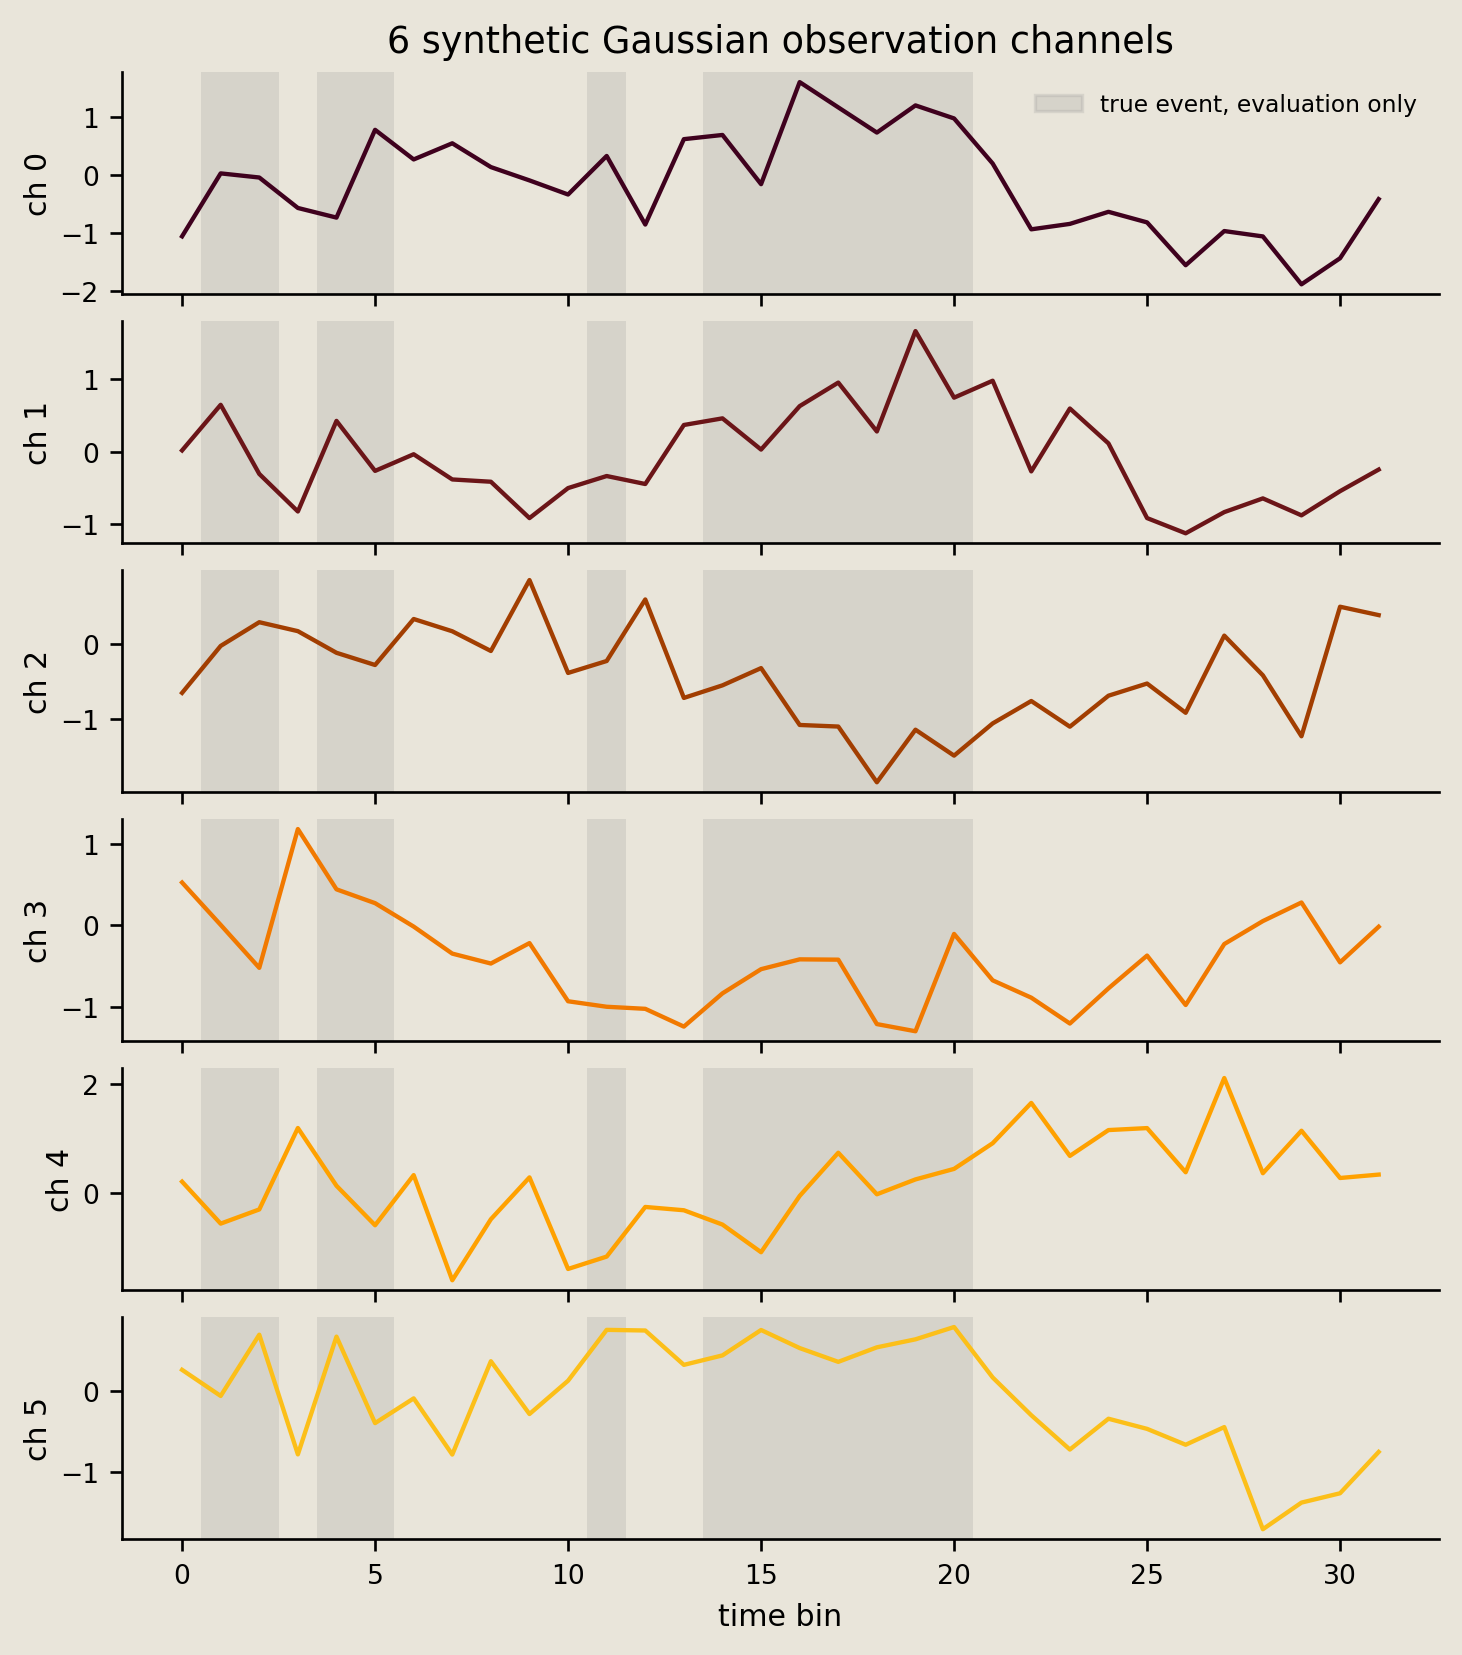

In [35]:
fig = P_fld.plot_observations(observations, true_event)
savefig(fig, "11_ssm_observations")

The gray bands identify the active event steps used only for evaluation.

The next plot compares `true_drive` with the offline Torx-smoothed `posterior_drive`, both projected onto `intent_axis`. It also shows the $\pm 2\sigma$ marginal band and the dashed full-trial median threshold.

The smoother and threshold use the complete 32-step trial.

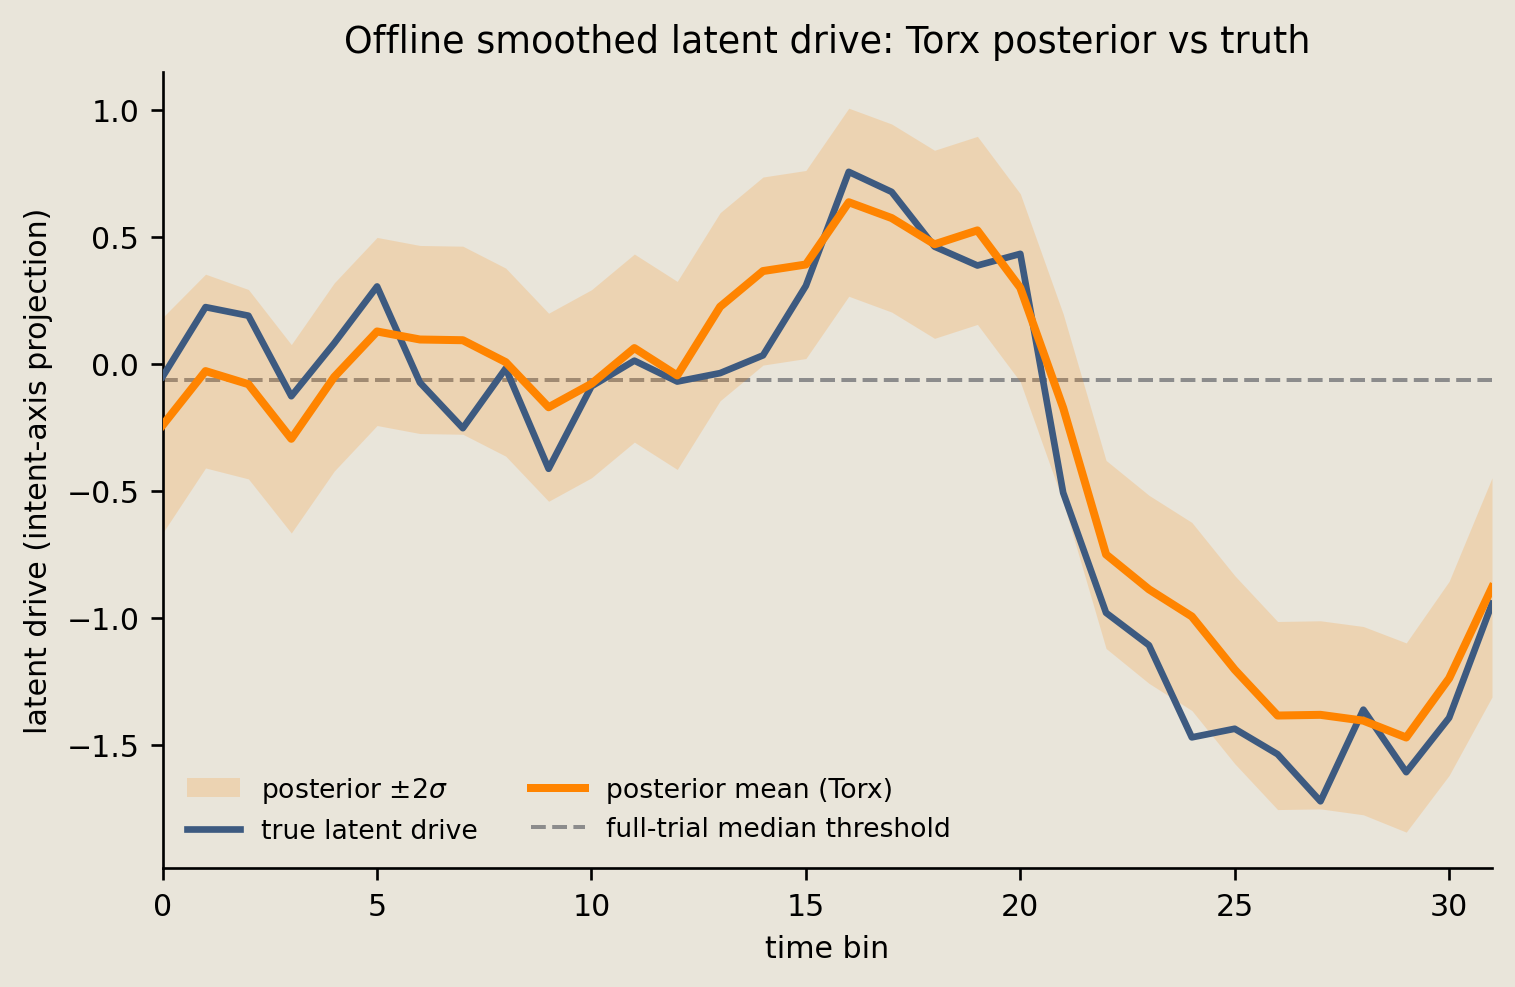

In [36]:
fig = P_fld.plot_posterior_drive(
    true_drive,
    posterior_drive,
    posterior_drive_std,
    detection_threshold,
)
savefig(fig, "11_ssm_posterior_drive")

The posterior mean tracks the latent drive in this seeded trial. The marginal uncertainty widens near the boundaries, where fewer observations surround a latent state.

The covariance plot shows the Frobenius norm of each $3 \times 3$ timestep block. Diagonal cells describe same-step uncertainty, the nearest-neighbor band is the strongest off-diagonal coupling, and longer-lag block norms are smaller in the check above.


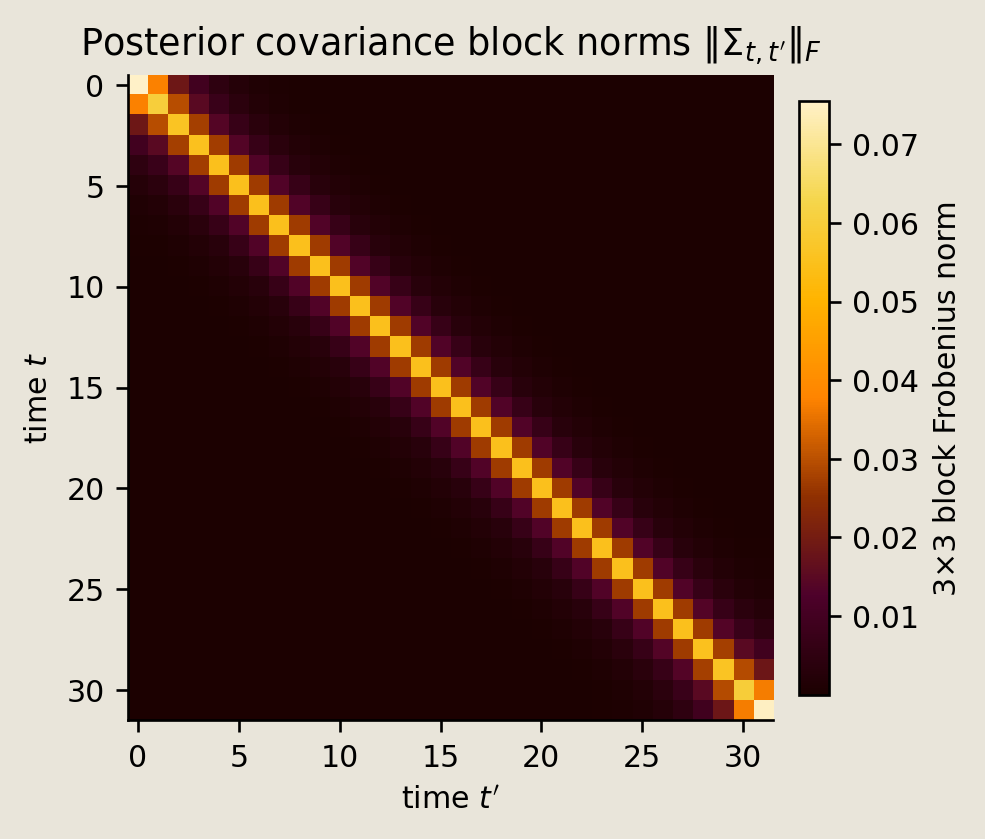

In [37]:
fig = P_fld.plot_posterior_covariance(block_norms)
savefig(fig, "11_ssm_covariance")

The block-norm covariance remains concentrated near the diagonal, as expected for local time-homogeneous dynamics.

The final plot shows the uncalibrated offline score and the resulting binary event bars for this one-seed oracle-axis sanity check.

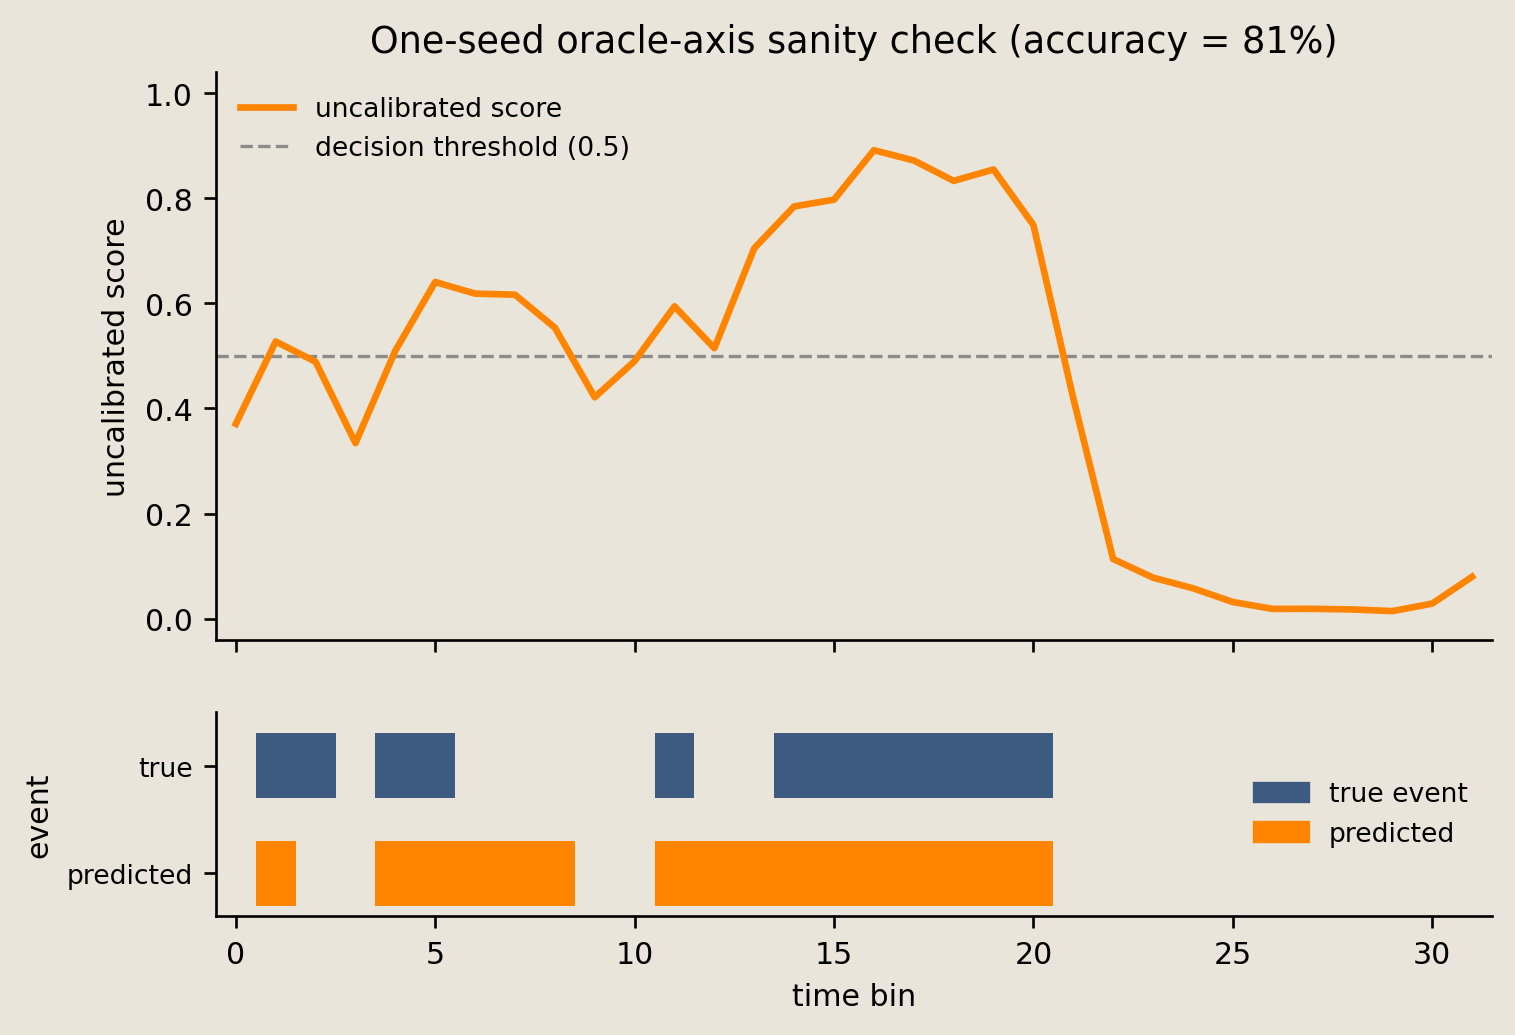

In [38]:
time = np.arange(T)
fig = P_fld.plot_detector(time, uncalibrated_score, true_event, predicted_event, accuracy)
savefig(fig, "11_ssm_detector")

The predicted bars align with most active intervals in this seeded oracle-axis check.

## Conclusion

We built a time-homogeneous linear-Gaussian state-space model in Torx and inspected an offline score from its exact smoothed posterior.

- The model is represented as 64 `AffineGaussianGate` instances, one initial gate plus one gate per transition and emission.
- Transition and emission gates alias fixed `theta` dictionaries at inference time while the circuit remains explicitly unrolled.
- `AffineGaussianSimulator.condition` returns the exact offline, acausal smoothed posterior and matches the dense NumPy reference to a relative tolerance of `1e-5`.
- The median-threshold metrics are a one-seed oracle-axis sanity check, and the logistic output is an uncalibrated score.
- Exact `-inf` passthrough log-variances are appropriate here but must be clamped before gradient training.

This tutorial applies the affine-Gaussian density layer of [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb) to a time series. To continue, work through [`12_langevin_graph_ising.ipynb`](12_langevin_graph_ising.ipynb).


## References

1. <span id="ref-kalman-1960"></span>Kalman, R.E. 1960. [*A new approach to linear filtering and prediction problems*](https://doi.org/10.1115/1.3662552). Trans. ASME J. Basic Eng. 82(1), 35-45.
2. <span id="ref-rts-1965"></span>Rauch, H.E., Tung, F., Striebel, C.T. 1965. [*Maximum likelihood estimates of linear dynamic systems*](https://doi.org/10.2514/3.3166). AIAA J. 3(8), 1445-1450.

